# Soccer Player Clasification
## Bibliotecas

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, silhouette_score

## Carga del dataset

In [59]:
df = pd.read_csv("data/fifa_players.csv")
print(df.head)

<bound method NDFrame.head of                  name                         full_name birth_date  age  \
0            L. Messi    Lionel Andrés Messi Cuccittini  6/24/1987   31   
1          C. Eriksen      Christian  Dannemann Eriksen  2/14/1992   27   
2            P. Pogba                        Paul Pogba  3/15/1993   25   
3          L. Insigne                   Lorenzo Insigne   6/4/1991   27   
4        K. Koulibaly                 Kalidou Koulibaly  6/20/1991   27   
...               ...                               ...        ...  ...   
17949     R. McKenzie                    Rory  McKenzie  10/7/1993   25   
17950       M. Sipľak                     Michal Sipľak   2/2/1996   23   
17951      J. Bekkema                       Jan Bekkema   4/9/1996   22   
17952      A. Al Yami               Abdulrahman Al Yami  6/19/1997   21   
17953  Júnior Brumado  José Francisco dos Santos Júnior  5/15/1999   19   

       height_cm  weight_kgs  positions   nationality  overall_rating

### Comprensión de los datos

In [60]:
#print(y)
print("DISTRIBUCION DE LAS CLASES POR POSICIÓN: \n",df["positions"].value_counts())
print("VALORES NULOS POR VARIABLE: \n",df.isnull().sum()) #Valores nulos por variable
print("TIPOS DE DATOS: \n",df.dtypes) #reconocer los tipos de datos

DISTRIBUCION DE LAS CLASES POR POSICIÓN: 
 positions
CB              2243
GK              2065
ST              1747
CM               764
CDM,CM           709
                ... 
LB,CM,LWB          1
CF,ST,LM,RM        1
CAM,CM,RW,LW       1
CF,LM,RM           1
CF,CAM,CM          1
Name: count, Length: 890, dtype: int64
VALORES NULOS POR VARIABLE: 
 name                                 0
full_name                            0
birth_date                           0
age                                  0
height_cm                            0
weight_kgs                           0
positions                            0
nationality                          0
overall_rating                       0
potential                            0
value_euro                         255
wage_euro                          246
preferred_foot                       0
international_reputation(1-5)        0
weak_foot(1-5)                       0
skill_moves(1-5)                     0
body_type              

## Preparación de los datos

### Detección de registros duplicados

In [ ]:
print(f"Total de registros originales: {len(df)}")
duplicados = df.duplicated().sum()
print(f"Registros duplicados detectados: {duplicados}")

if duplicados > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Registros tras eliminar duplicados: {len(df)}")
else:
    print("Sin duplicados. El dataset está limpio.")

In [ ]:
# Transformación de variables
df["preferred_foot"] = df["preferred_foot"].map({"Right": 1, "Left": 0})
df["preferred_foot"] = df["preferred_foot"].fillna(df["preferred_foot"].mode()[0])

# Agrupación de posiciones granulares en 4 categorías principales
pos_map = {
    "GK":  "GK",
    "CB": "DEF", "LB": "DEF", "RB": "DEF", "LWB": "DEF", "RWB": "DEF",
    "CDM": "MID", "CM": "MID", "CAM": "MID", "LM": "MID", "RM": "MID",
    "LAM": "MID", "RAM": "MID", "LCM": "MID", "RCM": "MID",
    "LDM": "MID", "RDM": "MID",
    "ST": "FWD", "CF": "FWD", "LW": "FWD", "RW": "FWD",
    "LS": "FWD", "RS": "FWD", "SS": "FWD",
}
df["position_raw"] = df["positions"].apply(lambda x: x.split(",")[0].strip())
df["position"] = df["position_raw"].map(pos_map).fillna("MID")

print("DISTRIBUCIÓN DE LAS 4 CLASES:")
print(df["position"].value_counts())

# Selección manual de variables
features = ["age", "weak_foot(1-5)", "height_cm", "weight_kgs", "preferred_foot", "skill_moves(1-5)", "crossing", "finishing", "heading_accuracy", "short_passing", "volleys", "dribbling", "curve", "freekick_accuracy", "long_passing", "ball_control", "acceleration", "sprint_speed", "agility", "reactions", "balance", "shot_power", "jumping", "stamina", "strength", "long_shots", "aggression", "interceptions", "positioning", "vision", "composure", "marking", "standing_tackle", "sliding_tackle"]
target = "position"

df_clean = df[features + [target]].dropna().reset_index(drop=True)
X = df_clean[features].copy()
y = df_clean[target]
print(f"\nDataset limpio: {len(df_clean)} registros | {y.nunique()} clases")

# ── Detección y corrección de outliers (IQR Capping) ─────────────────────────
outliers_info = {}
for col in X.select_dtypes(include=[np.number]).columns:
    Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((X[col] < lower) | (X[col] > upper)).sum()
    if n_out > 0:
        outliers_info[col] = int(n_out)
        X[col] = X[col].clip(lower=lower, upper=upper)

print(f"\nVariables con outliers detectados: {len(outliers_info)} / {len(features)}")
print(f"Total de valores corregidos por capping IQR: {sum(outliers_info.values())}")
print("Top 5 variables con más outliers:")
for col, cnt in sorted(outliers_info.items(), key=lambda kv: -kv[1])[:5]:
    print(f"  {col:<30} {cnt} valores")

# ── Escalamiento (StandardScaler) ─────────────────────────────────────────────
# Necesario para KNN (basado en distancias) y SVM (maximización de margen)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nEscalamiento aplicado: media≈0, std≈1 en {X_scaled.shape[1]} variables")

# ── Selección de variables con PCA (95% varianza explicada) ───────────────────
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

componentes = pd.DataFrame(pca.components_, columns=X.columns)
importancia = componentes.abs().sum(axis=0).sort_values(ascending=False)
print("\nLAS 15 VARIABLES MÁS IMPORTANTES:")
print(importancia[:15].to_string())
top15 = importancia[:15].index.tolist()
X = X[top15].copy()

DISTRIBUCIÓN DE LAS 4 CLASES:
position
MID    6668
DEF    5883
FWD    3338
GK     2065
Name: count, dtype: int64

Dataset: 17954 registros | 4 clases

LAS 15 VARIABLES MÁS IMPORTANTES:
reactions           3.608646
weight_kgs          3.524591
composure           3.373585
age                 3.108026
jumping             3.093635
strength            3.027748
height_cm           2.931880
stamina             2.741054
aggression          2.740509
vision              2.628510
balance             2.622800
long_passing        2.532271
sprint_speed        2.531827
skill_moves(1-5)    2.501448
preferred_foot      2.491600


## Muestra de la distribución de los datos con las 3 variables más importantes

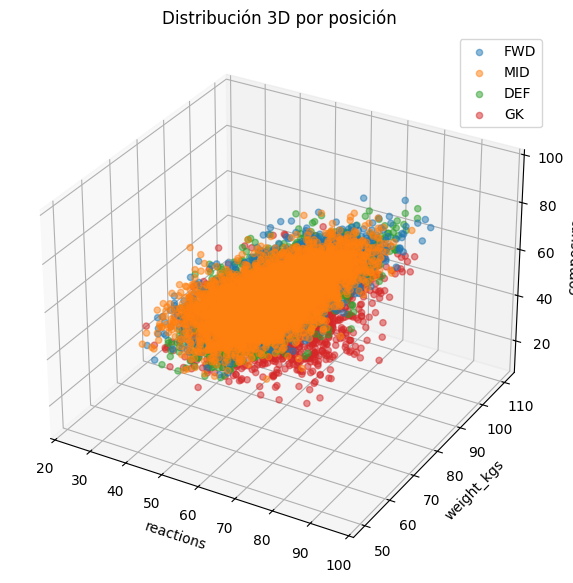

In [62]:
# Mapear categorías a colores
categorias = df["position"].unique()
colores = plt.cm.tab10(range(len(categorias)))
color_map = dict(zip(categorias, colores))

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for categoria, color in color_map.items():
    mask = df["position"] == categoria
    ax.scatter(
        X[mask].iloc[:, 0],
        X[mask].iloc[:, 1],
        X[mask].iloc[:, 2],
        label=categoria,
        color=color,
        alpha=0.5
    )

ax.set_xlabel(top15[0])
ax.set_ylabel(top15[1])
ax.set_zlabel(top15[2])
plt.title("Distribución 3D por posición")
plt.legend()
plt.show()

## Modelado
### División de datos en entrenamiento y prueba

In [63]:
# Escalar las top 15 variables para el modelado
scaler_model = StandardScaler()
X_model = scaler_model.fit_transform(X)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras")
print(f"Clases: {sorted(y.unique().tolist())}")

Entrenamiento: 14363 muestras | Prueba: 3591 muestras
Clases: ['DEF', 'FWD', 'GK', 'MID']


### K-Nearest Neighbors (KNN)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Silhouette Score — mide qué tan bien separados quedan los grupos según las
# predicciones del modelo. Rango: [-1, 1]. Más cercano a 1 = clusters más compactos.
sil_knn = silhouette_score(X_test, y_pred_knn)

print("=== K-Nearest Neighbors (KNN) ===")
print(f"Accuracy        : {accuracy_score(y_test, y_pred_knn):.4f} ({accuracy_score(y_test, y_pred_knn)*100:.2f}%)")
print(f"Silhouette Score: {sil_knn:.4f}  (cuánto se separan los grupos predichos, -1 a 1)")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_knn))

 K-Nearest Neighbors (KNN) 
Accuracy: 0.7736 (77.36%)

Reporte de clasificación:
              precision    recall  f1-score   support

         DEF       0.76      0.82      0.79      1177
         FWD       0.75      0.54      0.63       667
          GK       1.00      1.00      1.00       413
         MID       0.73      0.78      0.75      1334

    accuracy                           0.77      3591
   macro avg       0.81      0.79      0.79      3591
weighted avg       0.77      0.77      0.77      3591



### Support Vector Machine (SVM)

In [69]:
# GridSearchCV para encontrar los mejores hiperparámetros de SVM
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
}
svm_base = SVC(kernel='rbf', class_weight='balanced', random_state=42)
grid_search = GridSearchCV(svm_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor CV Accuracy: {grid_search.best_score_*100:.2f}%")

svm = grid_search.best_estimator_
y_pred_svm = svm.predict(X_test)

print(" Support Vector Machine (SVM) ")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f} ({accuracy_score(y_test, y_pred_svm)*100:.2f}%)")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm))

Mejores hiperparámetros: {'C': 1, 'gamma': 'scale'}
Mejor CV Accuracy: 81.56%
 Support Vector Machine (SVM) 
Accuracy: 0.8123 (81.23%)

Reporte de clasificación:
              precision    recall  f1-score   support

         DEF       0.85      0.83      0.84      1177
         FWD       0.66      0.76      0.71       667
          GK       1.00      1.00      1.00       413
         MID       0.80      0.76      0.78      1334

    accuracy                           0.81      3591
   macro avg       0.83      0.84      0.83      3591
weighted avg       0.82      0.81      0.81      3591



### Decision Tree

In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(" Decision Tree ")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f} ({accuracy_score(y_test, y_pred_dt)*100:.2f}%)")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_dt))

 Decision Tree 
Accuracy: 0.7530 (75.30%)

Reporte de clasificación:
              precision    recall  f1-score   support

         DEF       0.78      0.77      0.77      1177
         FWD       0.60      0.68      0.64       667
          GK       1.00      1.00      1.00       413
         MID       0.74      0.70      0.72      1334

    accuracy                           0.75      3591
   macro avg       0.78      0.79      0.78      3591
weighted avg       0.76      0.75      0.75      3591



## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,        # más árboles
    max_depth=20,            # controla sobreajuste
    min_samples_leaf=5,      # evita hojas muy pequeñas
    class_weight="balanced", # compensa desbalance entre clases
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} ({accuracy_score(y_test, y_pred_rf)*100:.2f}%)")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

## Comparación de Modelos

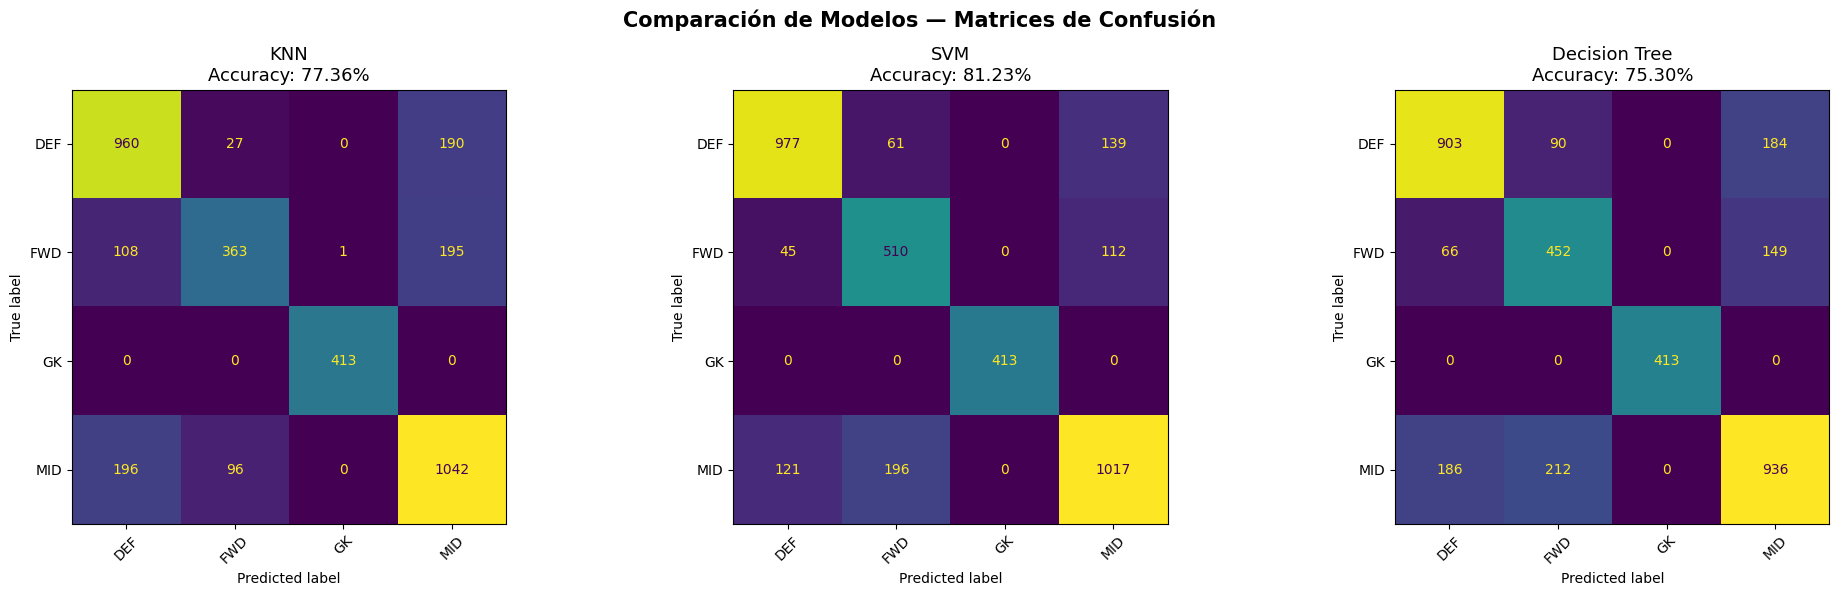


 COMPARACIÓN FINAL
Modelo                 Accuracy
--------------------------------
KNN                      77.36%
SVM                      81.23% => MEJOR
Decision Tree            75.30%

Mejor modelo: SVM con 81.23% de accuracy


In [71]:
modelos = ["KNN", "SVM", "Decision Tree"]
predicciones = [y_pred_knn, y_pred_svm, y_pred_dt]
accuracies = [accuracy_score(y_test, p) for p in predicciones]

# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, nombre, y_pred in zip(axes, modelos, predicciones):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, colorbar=False, xticks_rotation=45
    )
    ax.set_title(f"{nombre}\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%", fontsize=13)
plt.suptitle("Comparación de Modelos — Matrices de Confusión", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
print("\n COMPARACIÓN FINAL")
print(f"{'Modelo':<20} {'Accuracy':>10}")
print("-" * 32)
for nombre, acc in zip(modelos, accuracies):
    marca = " => MEJOR" if acc == max(accuracies) else ""
    print(f"{nombre:<20} {acc*100:>9.2f}%{marca}")

mejor_idx = accuracies.index(max(accuracies))
print(f"\nMejor modelo: {modelos[mejor_idx]} con {max(accuracies)*100:.2f}% de accuracy")

## Clasificación jerarquica

In [ ]:


pos_map = {
    "GK": "GK",
    # Defensas - solo distinguir central vs lateral
    "CB": "DEF_C",
    "LB": "DEF_L", "LWB": "DEF_L",   # fusionar LWB con LB
    "RB": "DEF_R", "RWB": "DEF_R",   # fusionar RWB con RB
    # Mediocampistas - defensivo, central y ofensivo
    "CDM": "MED_DEF", "LDM": "MED_DEF", "RDM": "MED_DEF",
    "CM": "MED_C", "LM": "MED_C", "RM": "MED_C",
    "CAM": "MED_O", "LAM": "MED_O", "RAM": "MED_O",
    "LCM": "MED_C", "RCM": "MED_C",  
    # Delanteros 
    "LW": "EX",
    "RW": "EX",
    "ST": "DC", "CF": "SD",
    "LS": "DC", "RS": "DC", "SS": "SD",
}

df["position_sub"] = df["position_raw"].map(pos_map)

jerarquia = {
    "GK":  ["GK"],
    "DEF": ["DEF_C", "DEF_L", "DEF_R"],
    "MID": ["MED_DEF", "MED_C", "MED_O"],
    "FWD": ["EX", "DC", "SD"]
}
modelos_nivel2 = {}

for posicion, subclases in jerarquia.items():
    if posicion != "GK":
        # Filtrar registros de esta posición general
        mask = df["position_sub"].isin(subclases)
        X_pos = df[mask][features]
        y_pos = df[mask]["position_sub"]
        
        X_train_pos, X_test_pos, y_train_pos, y_test_pos = train_test_split(X_pos, y_pos, test_size=0.2)
        
        modelo = RandomForestClassifier(class_weight="balanced", random_state=42)
        modelo.fit(X_train_pos, y_train_pos)
        modelos_nivel2[posicion] = modelo
        
        y_pred_pos = modelo.predict(X_test_pos)
        
        print(f"RESULTADOS DE LA POSICIÓN: {posicion}")
        print(f"Accuracy: {accuracy_score(y_test_pos, y_pred_pos):.4f} ({accuracy_score(y_test_pos, y_pred_pos)*100:.2f}%)")
        print("\nReporte de clasificación:")
        print(classification_report(y_test_pos, y_pred_pos))

print(df["position_sub"].value_counts())
print("Sin clasificar:", df["position_sub"].isna().sum())

## Expo Classification Model

Here we train a specific model using only features that can be easily asked or measured in a live Expo environment (e.g. age, height, weight, sprint speed, jumping, strength, stamina, shot power).

We want to see how accurately we can predict the position with just these physical and basic attributes.

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

expo_features = ['age', 'height_cm', 'weight_kgs', 'sprint_speed', 
                 'jumping', 'shot_power', 'stamina', 'strength']

# Ensure we drop NA values for these features
df_expo = df_clean.dropna(subset=expo_features + ['position_class']).copy()
X_expo = df_expo[expo_features].values
y_expo = df_expo['position_class'].values

# Train/Test split
X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(
    X_expo, y_expo, test_size=0.2, random_state=42, stratify=y_expo
)

# Scale
scaler_ex = StandardScaler()
X_train_scaled = scaler_ex.fit_transform(X_train_ex)
X_test_scaled = scaler_ex.transform(X_test_ex)

# Train SVM
svm_ex = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced', random_state=42)
svm_ex.fit(X_train_scaled, y_train_ex)

# Predict and Evaluate
y_pred_ex = svm_ex.predict(X_test_scaled)
print("Expo Model Classification Report:\n")
print(classification_report(y_test_ex, y_pred_ex))

# Plot confusion matrix
cm = confusion_matrix(y_test_ex, y_pred_ex, labels=svm_ex.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=svm_ex.classes_, yticklabels=svm_ex.classes_)
plt.title('Confusion Matrix - Expo Features Only')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()


## Expo Classification Model

Here we train a specific model using only features that can be easily asked or measured in a live Expo environment (e.g. age, height, weight, sprint speed, jumping, strength, stamina, shot power).

We want to see how accurately we can predict the position with just these physical and basic attributes.

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

expo_features = ['age', 'height_cm', 'weight_kgs', 'sprint_speed', 
                 'jumping', 'shot_power', 'stamina', 'strength']

# Ensure we drop NA values for these features
df_expo = df_clean.dropna(subset=expo_features + ['position_class']).copy()
X_expo = df_expo[expo_features].values
y_expo = df_expo['position_class'].values

# Train/Test split
X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(
    X_expo, y_expo, test_size=0.2, random_state=42, stratify=y_expo
)

# Scale
scaler_ex = StandardScaler()
X_train_scaled = scaler_ex.fit_transform(X_train_ex)
X_test_scaled = scaler_ex.transform(X_test_ex)

# Train SVM
svm_ex = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced', random_state=42)
svm_ex.fit(X_train_scaled, y_train_ex)

# Predict and Evaluate
y_pred_ex = svm_ex.predict(X_test_scaled)
print("Expo Model Classification Report:\n")
print(classification_report(y_test_ex, y_pred_ex))

# Plot confusion matrix
cm = confusion_matrix(y_test_ex, y_pred_ex, labels=svm_ex.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=svm_ex.classes_, yticklabels=svm_ex.classes_)
plt.title('Confusion Matrix - Expo Features Only')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()
